In [121]:
import pandas as pd
import bentoml
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
from pathlib import Path
project_root = Path.cwd().parents[0]

# --- CONFIGURATION ---
DATA_PATH = project_root / "data" / "All Data 2015-2025.csv"
# API_ENDPOINT = "http://localhost:3000" # Local
API_ENDPOINT = "https://8s3mfvbefu.eu-west-3.awsapprunner.com"  # AWS
N_SAMPLES = 100 # Nombre de bâtiments à tester
YEAR = 2017 #Année doit être une valeur numérique
TIMEOUT = 30  # Timeout en secondes

In [123]:

print(f"Chargement des nouvelles données depuis '{DATA_PATH}'...")
try:
    df_seattle = pd.read_csv(DATA_PATH, na_values=['', 'NULL', 'N/A', 'missing'], sep=";", thousands=',')
    # Year filter
    df_seattle = df_seattle[df_seattle["DataYear"] == YEAR]
    assert df_seattle.shape[0] > 0, f"Aucune donnée retrouvée pour l'année {YEAR}"
    print(f"Pour l'annéee {YEAR}, {df_seattle.shape[0]} lignes existes")
except FileNotFoundError:
    print(f"ERREUR : Fichier non trouvé. Vérifie le chemin dans la variable DATA_PATH.")
    exit()    

Chargement des nouvelles données depuis 'All Data 2015-2025.csv'...
Pour l'annéee 2017, 3286 lignes existes


In [124]:
# Appliquer le même nettoyage de base que pour l'entraînement
print("Nettoyage et filtrage des données...")

non_residential_types =[
    'NonResidential', 
    'Nonresidential COS', 
    'SPS-District K-12', 
    'Campus', 
    'Nonresidential WA'
]

df_non_residential = df_seattle[df_seattle["BuildingType"].isin(non_residential_types)].copy()
df_non_residential = df_non_residential.rename(columns={
    "PropertyGFABuildings" : "PropertyGFABuilding(s)",
    "EPAPropertyType" : "PrimaryPropertyType"
    })

Nettoyage et filtrage des données...


In [125]:
regex_residential = "Family|Residence|Residential"
mask_residential = (
                (df_non_residential["PrimaryPropertyType"].str.contains(regex_residential, case=False, na=False, regex=True))
                |(df_non_residential["LargestPropertyUseType"].str.contains(regex_residential, case=False, na=False, regex=True))
)
df_non_residential = df_non_residential.loc[~mask_residential].copy()

In [126]:

# Recréation de la colonne "ListOfAllPropertyUseTypes"
cols_uses = [
    "LargestPropertyUseType",
    "SecondLargestPropertyUseType",
    "ThirdLargestPropertyUseType",
]

# Combine proprement les usages non nuls
df_non_residential["ListOfAllPropertyUseTypes"] = (
    df_non_residential[cols_uses]
    .astype(str)
    .apply(lambda row: ", ".join([v for v in row if v and v.lower() != "nan"]), axis=1)
)

# Optionnel : supprimer les doublons dans la liste (tout en gardant l’ordre)
df_non_residential["ListOfAllPropertyUseTypes"] = df_non_residential["ListOfAllPropertyUseTypes"].apply(
    lambda s: ", ".join(dict.fromkeys(s.split(", ")))
)

df_non_residential["ListOfAllPropertyUseTypes"]

2                                  Hotel
12                                 Hotel
22         Office, Parking, Retail Store
32                        Hotel, Parking
45                                 Other
                      ...               
34338            Medical Office, Parking
34348            Police Station, Parking
34358                              Hotel
34368    Medical Office, Parking, Office
34378                       Retail Store
Name: ListOfAllPropertyUseTypes, Length: 1496, dtype: object

In [127]:
col = "PropertyGFABuilding(s)"
df_non_residential[col] = pd.to_numeric(df_non_residential[col], errors='coerce')
assert df_non_residential[col].dtype in ['float64', 'int64']
print(f"NaN count: {df_non_residential[col].isna().sum()}")

NaN count: 19


In [128]:
col = "PropertyGFAParking"
df_non_residential[col] = pd.to_numeric(df_non_residential[col], errors='coerce')
assert df_non_residential[col].dtype in ['float64', 'int64']
print(f"NaN count: {df_non_residential[col].isna().sum()}")

NaN count: 0


In [129]:
col = "SiteEnergyUse(kBtu)"
df_non_residential[col] = pd.to_numeric(df_non_residential[col], errors='coerce')
assert df_non_residential[col].dtype in ['float64', 'int64']
print(f"NaN count: {df_non_residential[col].isna().sum()}")

NaN count: 16


In [130]:
# Harmonisation de types
df_non_residential["CouncilDistrictCode"]  = df_non_residential["CouncilDistrictCode"].astype("str")

# Imputation de ENERGYSTARScore
# median_energy_star_score = 73.0
# print(f"{median_energy_star_score=}")
# df_non_residential["has_energy_score"] = df_non_residential["ENERGYSTARScore"].notna().astype(int)
# df_non_residential["ENERGYSTARScore"] = df_non_residential["ENERGYSTARScore"].fillna(median_energy_star_score)

# Capitalisation de chaque mot dans "Neighborhood"
df_non_residential["Neighborhood"] = df_non_residential["Neighborhood"].str.title()

# Mapping des valeurs catégoriques manquantes
df_non_residential["ComplianceStatus"] = df_non_residential["ComplianceStatus"].replace({
    "Not Compliant": "Non-Compliant"
})

In [131]:
df_non_residential.shape

(1496, 24)

In [132]:
# Colonnes requises par notre API (basé sur validation.py)
required_columns = [
    "OSEBuildingID", #  Util pour le relevé d'erreurs
    "BuildingType", "CouncilDistrictCode", "Neighborhood", "LargestPropertyUseType",
    "ComplianceStatus", "YearBuilt", "NumberofBuildings", "NumberofFloors",
    "PropertyGFAParking", "PropertyGFABuilding(s)", "ENERGYSTARScore",
    "ListOfAllPropertyUseTypes", # On le renommera en AllPropertyUseTypes
    "SiteEnergyUse(kBtu)" # Notre vérité terrain pour comparer
]
# Features qui ne doivent pas être vide
mandatory_columns  = [col for col in required_columns if col != "ENERGYSTARScore"]

# On supprime les lignes où il manque une donnée essentielle
df_test = df_non_residential[required_columns].dropna(subset=mandatory_columns )
df_test


,OSEBuildingID,BuildingType,CouncilDistrictCode,Neighborhood,LargestPropertyUseType,ComplianceStatus,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFAParking,PropertyGFABuilding(s),ENERGYSTARScore,ListOfAllPropertyUseTypes,SiteEnergyUse(kBtu)
2,1,NonResidential,7,Downtown,Hotel,Compliant,1927,1.0,12,0,88434.0,62.0,Hotel,7361655.0
12,10,NonResidential,7,Downtown,Hotel,Compliant,1926,1.0,11,0,83008.0,49.0,Hotel,5901084.0
22,100,NonResidential,7,Lake Union,Office,Compliant,2010,2.0,5,150726,287367.0,87.0,"Office, Parking, Retail Store",16381541.0
32,102,NonResidential,7,Lake Union,Hotel,Compliant,1990,1.0,7,44766,238097.0,62.0,"Hotel, Parking",19158784.0
45,104,Nonresidential COS,7,Magnolia / Queen Anne,Other,Compliant,1962,1.0,1,0,65127.0,NaN,Other,5967398.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34338,89,NonResidential,3,East,Medical Office,Compliant,1965,2.0,3,150475,179014.0,56.0,"Medical Office, Parking",14823875.0
34348,9,Nonresidential COS,7,Downtown,Police Station,Non-Compliant,1999,1.0,2,37198,6009.0,NaN,"Police Station, Parking",13250532.0
34358,95,NonResidential,3,East,Hotel,Compliant,1908,1.0,7,0,76631.0,69.0,Hotel,7563180.0
34368,96,NonResidential,3,East,Medical Office,Non-Compliant,1983,1.0,6,24316,96783.0,NaN,"Medical Office, Parking, Office",14841480.0


In [133]:
# Remplacement des NaN par None
print(f"None count before : {df_test["ENERGYSTARScore"].apply(lambda x: x is None).sum()} | dtype: {df_test['ENERGYSTARScore'].dtype}")

df_test["ENERGYSTARScore"] = df_test["ENERGYSTARScore"].replace({np.nan: None})

print(f"None count after : {df_test["ENERGYSTARScore"].apply(lambda x: x is None).sum()} | dtype: {df_test['ENERGYSTARScore'].dtype}")

None count before : 0 | dtype: float64
None count after : 468 | dtype: object


In [134]:
# On prend un échantillon aléatoire
if len(df_test) > N_SAMPLES:
    df_sample = df_test.sample(n=N_SAMPLES, random_state=42)
else:
    df_sample = df_test # Si on a moins de 10 lignes valides, on prend tout
    
print(f"{len(df_sample)} bâtiments sélectionnés pour le test.\n")
df_sample

100 bâtiments sélectionnés pour le test.



,OSEBuildingID,BuildingType,CouncilDistrictCode,Neighborhood,LargestPropertyUseType,ComplianceStatus,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFAParking,PropertyGFABuilding(s),ENERGYSTARScore,ListOfAllPropertyUseTypes,SiteEnergyUse(kBtu)
8982,22078,NonResidential,3,Central,Worship Facility,Compliant,1901,1.0,2,0,2656.0,3.0,Worship Facility,1776214.0
14357,24218,NonResidential,1,Greater Duwamish,Manufacturing/Industrial Plant,Compliant,1952,1.0,1,0,396.0,64.0,"Manufacturing/Industrial Plant, Non-Refrigerat...",1061450.0
26318,40447,Nonresidential COS,1,Greater Duwamish,Office,Compliant,1966,5.0,1,0,90072.0,None,"Office, Non-Refrigerated Warehouse, Other",9390903.0
14973,24461,NonResidential,1,Greater Duwamish,Retail Store,Compliant,1975,1.0,1,0,43794.0,88.0,"Retail Store, Office",1300198.0
26022,383,NonResidential,1,Downtown,Office,Compliant,1912,1.0,42,0,304346.0,72.0,"Office, Retail Store, Other - Restaurant/Bar",25739626.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8355,21794,NonResidential,3,East,K-12 School,Compliant,1968,1.0,5,0,636.0,47.0,K-12 School,2342854.0
25177,316,NonResidential,7,Downtown,Hotel,Compliant,2003,1.0,8,38757,254273.0,35.0,"Hotel, Parking",27247592.0
31866,552,NonResidential,1,Greater Duwamish,Distribution Center,Compliant,1968,1.0,1,0,174227.0,27.0,"Distribution Center, Office",9687446.0
27512,49725,NonResidential,3,East,Hospital (General Medical & Surgical),Compliant,2012,1.0,7,0,26747.0,48.0,"Hospital (General Medical & Surgical), Other",42629608.0


🧪 TEST DE L'API EN PRODUCTION SUR DES DONNÉES RÉELLES

📊 Échantillon à tester :
   - Nombre de bâtiments : 100
   - Colonnes disponibles : ['OSEBuildingID', 'BuildingType', 'CouncilDistrictCode', 'Neighborhood', 'LargestPropertyUseType', 'ComplianceStatus', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'ENERGYSTARScore', 'ListOfAllPropertyUseTypes', 'SiteEnergyUse(kBtu)']

🔄 Appels API en cours...


Prédictions:   7%|▋         | 7/100 [00:01<00:14,  6.27it/s]

Prédictions: 100%|██████████| 100/100 [00:14<00:00,  6.67it/s]



📈 ANALYSE DES RÉSULTATS

📊 Métriques de performance :
   - Nombre de prédictions réussies : 100
   - MAE (Mean Absolute Error)      : 3,339,737.12 kBtu
   - RMSE (Root Mean Squared Error) : 6,759,103.61 kBtu
   - R² Score                       : 0.5605
   - MAPE (Mean Abs % Error)        : 51.62%

⚠️  Warnings :
   - Prédictions avec warnings : 38/100 (38.0%)

   Détails des warnings :
      Index 26318: ['Avertissement : ENERGYSTARScore non fourni, remplacé par la médiane.La prédiction peut être moins précise.']
      Index 6687: ['Avertissement : ENERGYSTARScore non fourni, remplacé par la médiane.La prédiction peut être moins précise.']
      Index 7173: ['Avertissement : ENERGYSTARScore non fourni, remplacé par la médiane.La prédiction peut être moins précise.']
      Index 21863: ['Avertissement : ENERGYSTARScore non fourni, remplacé par la médiane.La prédiction peut être moins précise.']
      Index 32079: ['Avertissement : ENERGYSTARScore non fourni, remplacé par la médiane.La 

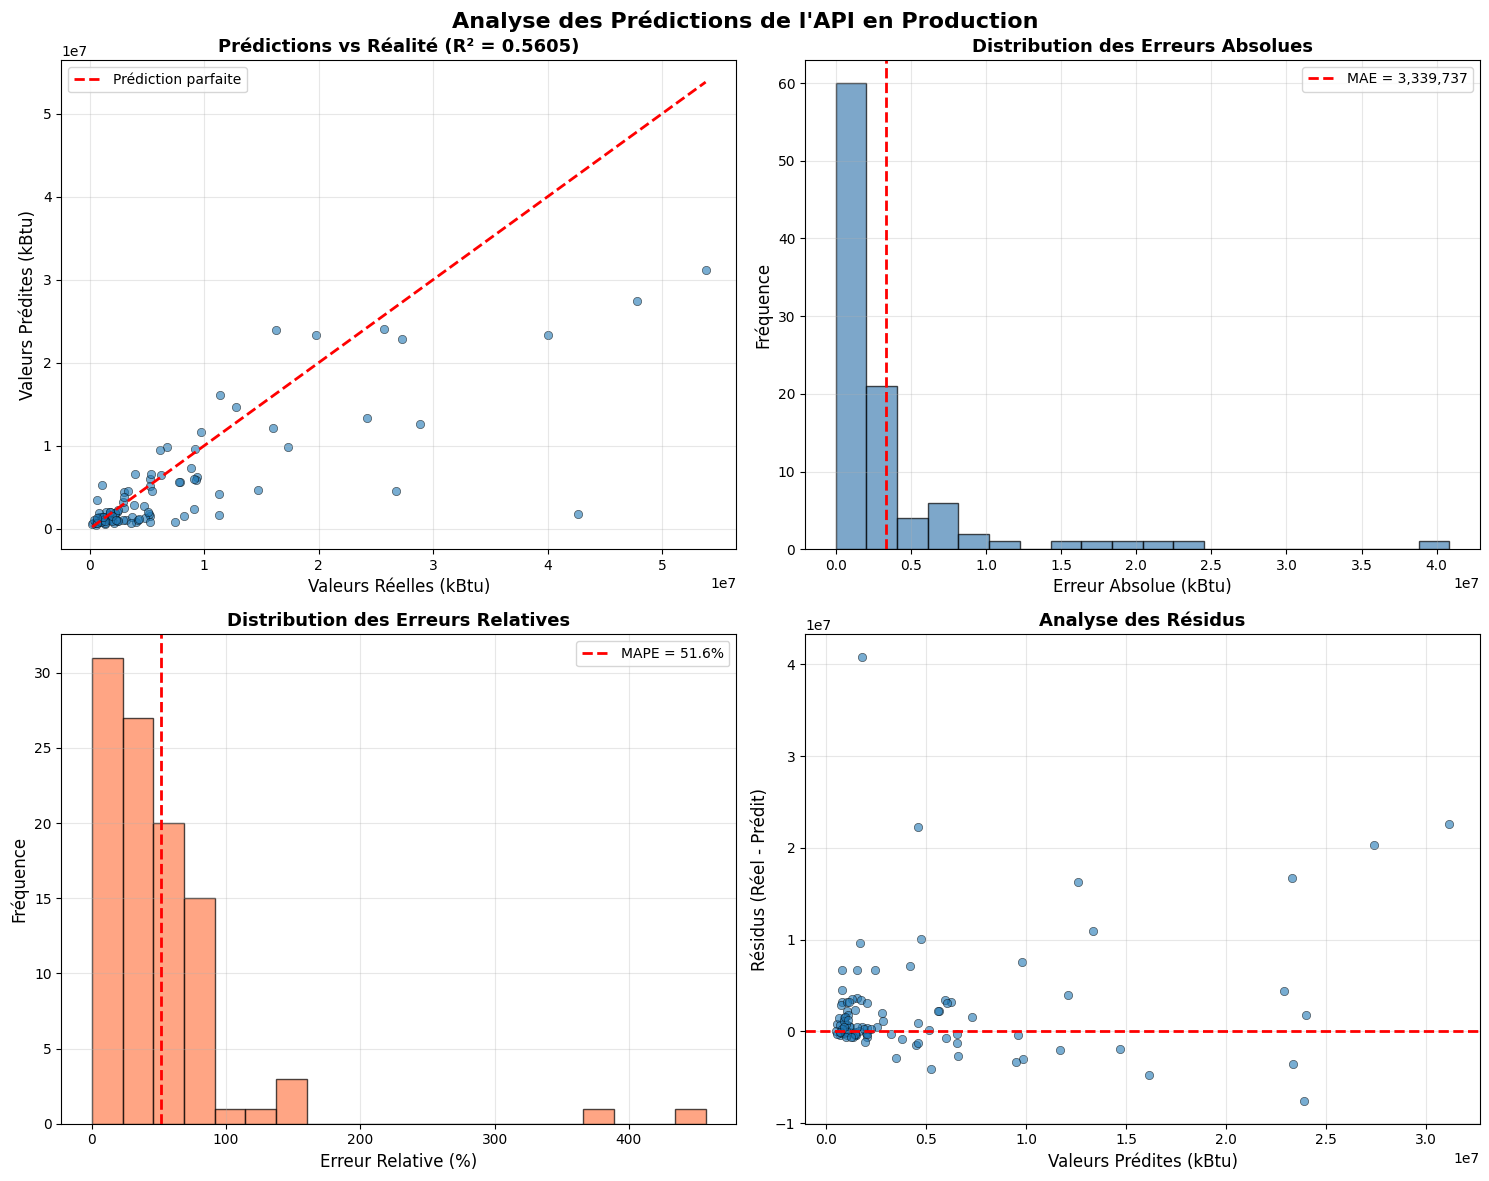


💾 Résultats sauvegardés dans 'resultats_api_production.csv'

✅ Aucune erreur d'API ! Tous les appels ont réussi.

🎉 TESTS TERMINÉS !


In [135]:
print("="*80)
print("🧪 TEST DE L'API EN PRODUCTION SUR DES DONNÉES RÉELLES")
print("="*80)

# --- ÉTAPE 1 : PRÉPARER LES DONNÉES ---
print("\n📊 Échantillon à tester :")
print(f"   - Nombre de bâtiments : {len(df_sample)}")
print(f"   - Colonnes disponibles : {list(df_sample.columns)}")

# --- ÉTAPE 2 : INTERROGER L'API EN BOUCLE ---
print("\n🔄 Appels API en cours...")

results = []
errors = []

with bentoml.SyncHTTPClient(API_ENDPOINT, timeout=TIMEOUT) as client:
    for index, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc="Prédictions"):
        
        # Préparer le payload JSON pour l'API
        payload = {
            # "BuildingType": str(row["BuildingType"]),
            # "CouncilDistrictCode": str(row["CouncilDistrictCode"]),
            # "Neighborhood": str(row["Neighborhood"]),
            "LargestPropertyUseType": str(row["LargestPropertyUseType"]),
            # "ComplianceStatus": str(row["ComplianceStatus"]),
            "ListOfAllPropertyUseTypes": str(row["ListOfAllPropertyUseTypes"]),
            "YearBuilt": int(row["YearBuilt"]),
            "NumberofBuildings": int(row["NumberofBuildings"]),
            "NumberofFloors": int(row["NumberofFloors"]),
            "PropertyGFAParking": float(row["PropertyGFAParking"]),
            "PropertyGFABuilding_s_": float(row["PropertyGFABuilding(s)"]),
            # "ENERGYSTARScore": float(row["ENERGYSTARScore"]),
            "ENERGYSTARScore": row["ENERGYSTARScore"],
        }

        try:
            # Envoyer la requête
            response = client.predict(data=payload)
            
            # Stocker les résultats
            results.append({
                "index": index,
                "OSEBuildingID": row["OSEBuildingID"],
                "valeur_reelle": float(row["SiteEnergyUse(kBtu)"]),
                "valeur_predite": float(response.get("predicted_SiteEnergyUse(kBtu)")),
                "erreur_absolue": abs(float(row["SiteEnergyUse(kBtu)"]) - float(response.get("predicted_SiteEnergyUse(kBtu)"))),
                "erreur_relative_pct": abs(float(row["SiteEnergyUse(kBtu)"]) - float(response.get("predicted_SiteEnergyUse(kBtu)"))) / float(row["SiteEnergyUse(kBtu)"]) * 100,
                "warnings": response.get("warning_messages", None),
                "has_warning": bool(response.get("warning_messages"))
            })
            
        except Exception as e:
            errors.append({
                "index": index,
                "error": str(e),
                "payload": payload
            })
            print(f"\n⚠️  Erreur à l'index {index}: {e}")

# --- ÉTAPE 3 : ANALYSER LES RÉSULTATS ---
print("\n" + "="*80)
print("📈 ANALYSE DES RÉSULTATS")
print("="*80)

if not results:
    print("❌ Aucune prédiction réussie !")
else:
    # Créer un DataFrame des résultats
    df_results = pd.DataFrame(results)
    
    # Métriques globales
    y_true = df_results["valeur_reelle"]
    y_pred = df_results["valeur_predite"]
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = df_results["erreur_relative_pct"].mean()
    
    print(f"\n📊 Métriques de performance :")
    print(f"   - Nombre de prédictions réussies : {len(results)}")
    print(f"   - MAE (Mean Absolute Error)      : {mae:,.2f} kBtu")
    print(f"   - RMSE (Root Mean Squared Error) : {rmse:,.2f} kBtu")
    print(f"   - R² Score                       : {r2:.4f}")
    print(f"   - MAPE (Mean Abs % Error)        : {mape:.2f}%")
    
    # Statistiques sur les warnings
    nb_warnings = df_results["has_warning"].sum()
    print(f"\n⚠️  Warnings :")
    print(f"   - Prédictions avec warnings : {nb_warnings}/{len(results)} ({nb_warnings/len(results)*100:.1f}%)")
    
    if nb_warnings > 0:
        print(f"\n   Détails des warnings :")
        for idx, row in df_results[df_results["has_warning"]].iterrows():
            print(f"      Index {row['index']}: {row['warnings']}")
    
    # Top 5 meilleures prédictions
    print(f"\n✅ Top 5 meilleures prédictions (erreur absolue la plus faible) :")
    top_best = df_results.nsmallest(5, "erreur_absolue")[["index", "valeur_reelle", "valeur_predite", "erreur_absolue", "erreur_relative_pct"]]
    print(top_best.to_string(index=False))
    
    # Top 5 pires prédictions
    print(f"\n❌ Top 5 pires prédictions (erreur absolue la plus élevée) :")
    top_worst = df_results.nlargest(5, "erreur_absolue")[["index", "valeur_reelle", "valeur_predite", "erreur_absolue", "erreur_relative_pct"]]
    print(top_worst.to_string(index=False))
    
    # --- ÉTAPE 4 : VISUALISATIONS ---
    print(f"\n📊 Génération des graphiques...")
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle("Analyse des Prédictions de l'API en Production", fontsize=16, fontweight='bold')
    
    # 1. Scatter plot : Valeurs réelles vs prédites
    ax1 = axes[0, 0]
    ax1.scatter(y_true, y_pred, alpha=0.6, edgecolors='k', linewidth=0.5)
    ax1.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2, label='Prédiction parfaite')
    ax1.set_xlabel("Valeurs Réelles (kBtu)", fontsize=12)
    ax1.set_ylabel("Valeurs Prédites (kBtu)", fontsize=12)
    ax1.set_title(f"Prédictions vs Réalité (R² = {r2:.4f})", fontsize=13, fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # 2. Distribution des erreurs absolues
    ax2 = axes[0, 1]
    ax2.hist(df_results["erreur_absolue"], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    ax2.axvline(mae, color='red', linestyle='--', linewidth=2, label=f'MAE = {mae:,.0f}')
    ax2.set_xlabel("Erreur Absolue (kBtu)", fontsize=12)
    ax2.set_ylabel("Fréquence", fontsize=12)
    ax2.set_title("Distribution des Erreurs Absolues", fontsize=13, fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # 3. Distribution des erreurs relatives (%)
    ax3 = axes[1, 0]
    ax3.hist(df_results["erreur_relative_pct"], bins=20, edgecolor='black', alpha=0.7, color='coral')
    ax3.axvline(mape, color='red', linestyle='--', linewidth=2, label=f'MAPE = {mape:.1f}%')
    ax3.set_xlabel("Erreur Relative (%)", fontsize=12)
    ax3.set_ylabel("Fréquence", fontsize=12)
    ax3.set_title("Distribution des Erreurs Relatives", fontsize=13, fontweight='bold')
    ax3.legend()
    ax3.grid(alpha=0.3)
    
    # 4. Résidus
    ax4 = axes[1, 1]
    residus = y_true - y_pred
    ax4.scatter(y_pred, residus, alpha=0.6, edgecolors='k', linewidth=0.5)
    ax4.axhline(0, color='red', linestyle='--', linewidth=2)
    ax4.set_xlabel("Valeurs Prédites (kBtu)", fontsize=12)
    ax4.set_ylabel("Résidus (Réel - Prédit)", fontsize=12)
    ax4.set_title("Analyse des Résidus", fontsize=13, fontweight='bold')
    ax4.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Sauvegarder les résultats
    df_results.to_csv("resultats_api_production.csv", index=False)
    print(f"\n💾 Résultats sauvegardés dans 'resultats_api_production.csv'")

# --- ÉTAPE 5 : RAPPORT DES ERREURS ---
if errors:
    print("\n" + "="*80)
    print(f"⚠️  ERREURS RENCONTRÉES ({len(errors)} échecs)")
    print("="*80)
    for err in errors:
        print(f"\n   Index {err['index']}:")
        print(f"   Erreur: {err['error']}")
        print(f"   Payload: {err['payload']}")
else:
    print("\n✅ Aucune erreur d'API ! Tous les appels ont réussi.")

print("\n" + "="*80)
print("🎉 TESTS TERMINÉS !")
print("="*80)